# Deliverable 4 — PCA (dimensionality reduction)

This notebook is the **demo artifact** for the additional ML method. It uses the same eligible players and **train/test split** as supervised modeling (`random_state=42`, 20% test). **Imputation, scaling, and PCA are fit on the training split only** to avoid leakage.

- **Wider features** than Deliverable 3: `cbb_advanced_*`, `cbb_per100_*`, `cbb_totals_*`, plus `nba_debut_age` and rookie position dummies (**no recruiting**, same as supervised). Columns with more than 50% missing are excluded before PCA.
- **PCA** keeps enough components to explain **90%** of training variance (`sklearn.decomposition.PCA`).
- **Outputs:** CSVs under `outputs/unsupervised/`, figures under `progress/figures/` — same as running `python -m src.models.pca_analysis` from the repo root.
- **Note:** The next cell **reloads** `pca_analysis` before running so Jupyter does not keep an old in-memory copy (which would write to the wrong folder after you pull edits). You can also use **Restart kernel** then **Run all**.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
import importlib

import src.models.pca_analysis as pca_analysis

importlib.reload(pca_analysis)
summary = pca_analysis.main()

{
  "n_players": 595,
  "n_features_pca": 80,
  "n_components": 13,
  "cumulative_variance_last_pc": 0.908309249503672,
  "train_test_split": {
    "test_size": 0.2,
    "random_state": 42
  },
  "pca_target_variance": 0.9,
  "feature_columns": [
    "cbb_advanced_3PAr",
    "cbb_advanced_ASTpct",
    "cbb_advanced_BLKpct",
    "cbb_advanced_BPM",
    "cbb_advanced_DBPM",
    "cbb_advanced_DRBpct",
    "cbb_advanced_DWS",
    "cbb_advanced_FTr",
    "cbb_advanced_G",
    "cbb_advanced_GS",
    "cbb_advanced_MP",
    "cbb_advanced_OBPM",
    "cbb_advanced_ORBpct",
    "cbb_advanced_OWS",
    "cbb_advanced_PER",
    "cbb_advanced_PProd",
    "cbb_advanced_STLpct",
    "cbb_advanced_TOVpct",
    "cbb_advanced_TRBpct",
    "cbb_advanced_TSpct",
    "cbb_advanced_USGpct",
    "cbb_advanced_WS",
    "cbb_advanced_WS_40",
    "cbb_per100_2P",
    "cbb_per100_2PA",
    "cbb_per100_2Ppct",
    "cbb_per100_3P",
    "cbb_per100_3PA",
    "cbb_per100_3Ppct",
    "cbb_per100_AST",
    "cbb_per100_B

## Results

Figures and tables are generated above and saved to `progress/figures/` and `outputs/unsupervised/`. The cells below display them inline for easy review.

Players: 595  |  Features: 80  |  Components (90% variance): 13  |  Cumulative variance: 90.8%



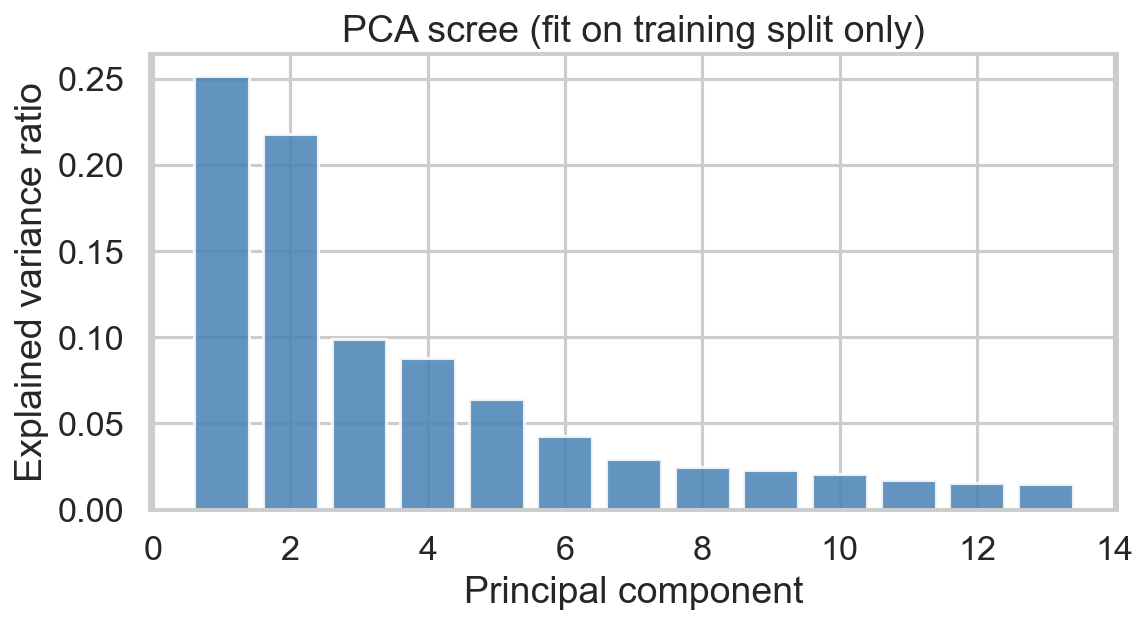

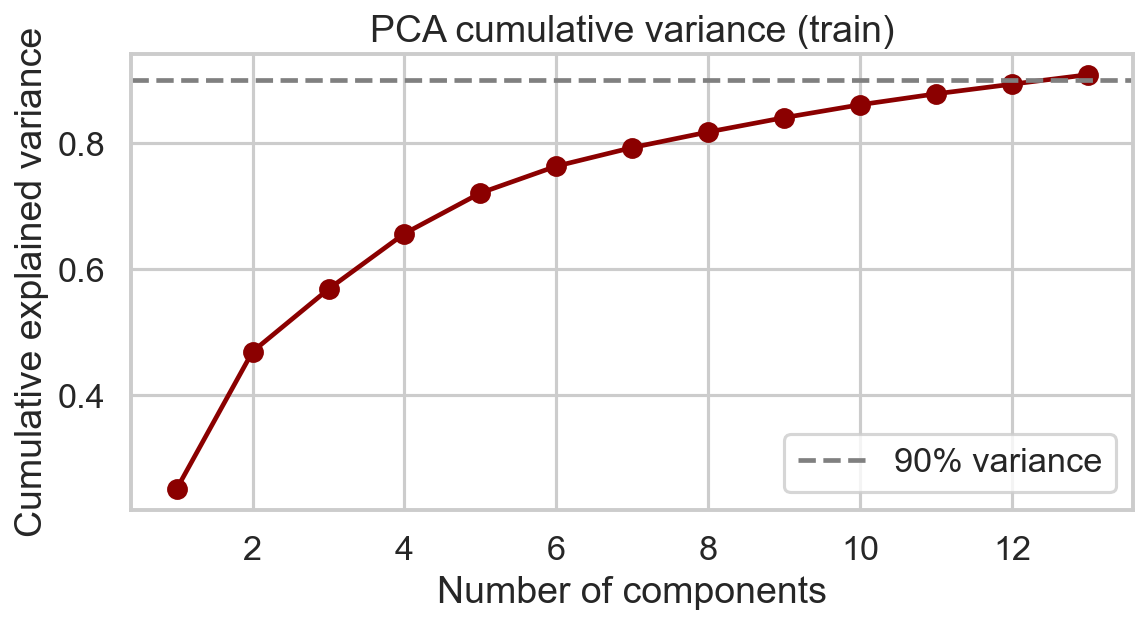

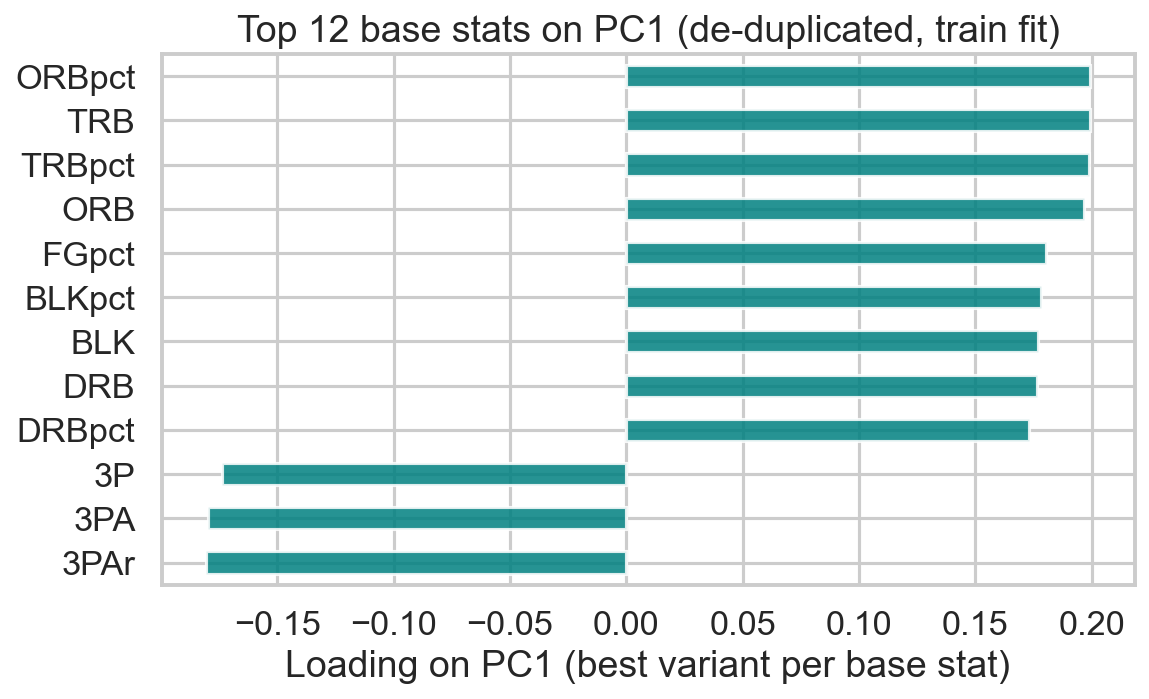

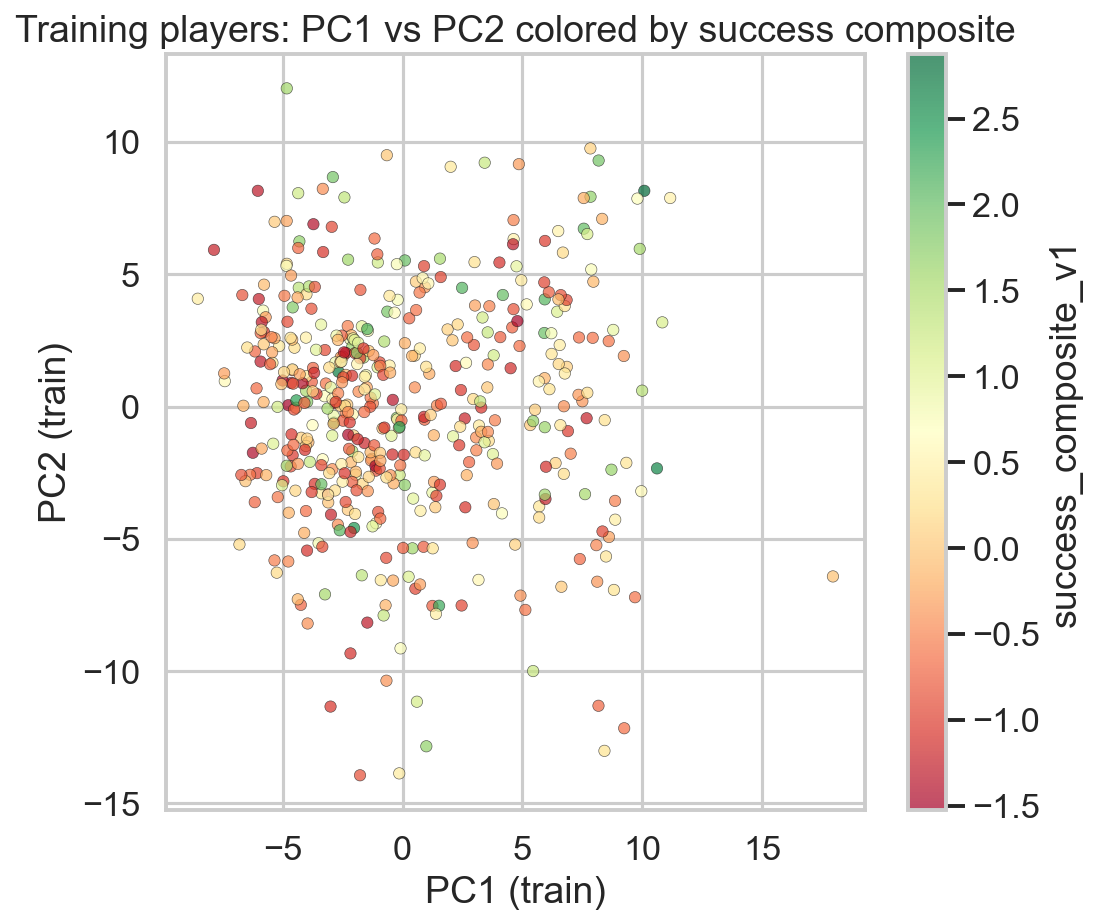

In [3]:
from pathlib import Path
from IPython.display import display, Image

fig_dir = Path("progress/figures")

print(f"Players: {summary['n_players']}  |  "
      f"Features: {summary['n_features_pca']}  |  "
      f"Components (90% variance): {summary['n_components']}  |  "
      f"Cumulative variance: {summary['cumulative_variance_last_pc']:.1%}")
print()

for name in ["pca_scree.png", "pca_cumulative_variance.png",
             "pca_pc1_loadings_bar.png", "pca_pc1_pc2_train_scatter.png"]:
    display(Image(filename=str(fig_dir / name), width=650))

In [4]:
import pandas as pd

corr = pd.read_csv("outputs/unsupervised/pca_pc_success_correlation.csv")
print("Pearson r between each PC and success_composite_v1:\n")
pivot = corr.pivot(index="pc", columns="split", values="r_success").round(3)
pivot = pivot[["train", "test"]]
pivot.index.name = None
display(pivot)

Pearson r between each PC and success_composite_v1:



split,train,test
PC1,0.142,0.022
PC10,-0.062,-0.139
PC11,0.003,0.006
PC12,-0.150,-0.034
PC13,-0.149,-0.122
PC2,0.105,0.065
PC3,0.038,0.236
PC4,-0.003,0.167
PC5,0.208,0.190
PC6,-0.075,-0.065


## Interpretation

- **PC1** contrasts **rebounding / interior** stats (ORB%, TRB%, BLK%, FG%) against **three-point volume** (3PAr, 3PA, 3P). It is a **role axis**, not a quality axis.
- PC-success correlations are **modest** (|r| < 0.25), consistent with supervised R-squared near 0.15 -- pre-NBA stats weakly predict the composite.
- Full interpretation and tie-in to supervised models: `progress/04_unsupervised.md`.